<a href="https://colab.research.google.com/github/zdamnda-blip/analisis_regresi_Zaskia_Dian_Amanda-/blob/main/tugas_analisis_regresi_Zaskia_Dian_Amanda_F5512510031.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TUGAS MATA KULIAH STATISTIKA DAN PROBABILITAS : ANALISIS REGRESI

NAMA : Zaskia Dian Amanda
NIM : F5512510031
KELAS : TEKNIK INFORMATIKA A ANGKATAN 2025

In [2]:
print("TUGAS MATA KULIAH STATISTIKA DAN PROBABILITAS : ANALISIS REGRESI")
print("NAMA : Zaskia Dian Amanda")
print("NIM : F5512510031")
print("KELAS : Teknik Informartika A Angkatan 2025")
print()

print("IDENTITAS DATASET")
print("=================")
print("Judul Analisis     : Analisis Regresi Linear Produksi Perikanan Tangkap Laut Indonesia")
print("Nama Dataset       : Panel Data Perikanan Indonesia 2019-2024")
print("Nama File          : fix.panel data perikanan 2019-2024.xlsx")
print("Link File          : https://docs.google.com/spreadsheets/d/1jvLY5h10XNeN6CJtAmFzR0Cp9Sofmgu9/edit?usp=sharing")
print("Sumber Dataset     : Badan Pusat Statistik (BPS) & Kementerian Kelautan dan Perikanan (KKP)")
print("Jenis Data         : Data panel produksi perikanan tangkap laut per provinsi")
print("Studi Kasus        : Analisis produksi perikanan tangkap Indonesia berdasarkan tren tahun, jumlah nelayan, jumlah kapal, dan ukuran kapal")
print("Metode             : Regresi Linear Berganda")
print("Variabel Target Y  : Produksi Perikanan Tangkap Laut (Ton)")
print("Variabel X         : Tahun, Provinsi, Jumlah Nelayan, Jumlah Kapal Total, dan Ukuran Kapal (GT)")

TUGAS MATA KULIAH STATISTIKA DAN PROBABILITAS : ANALISIS REGRESI
NAMA : Zaskia Dian Amanda
NIM : F5512510031
KELAS : Teknik Informartika A Angkatan 2025

IDENTITAS DATASET
Judul Analisis     : Analisis Regresi Linear Produksi Perikanan Tangkap Laut Indonesia
Nama Dataset       : Panel Data Perikanan Indonesia 2019-2024
Nama File          : fix.panel data perikanan 2019-2024.xlsx
Link File          : https://docs.google.com/spreadsheets/d/1jvLY5h10XNeN6CJtAmFzR0Cp9Sofmgu9/edit?usp=sharing
Sumber Dataset     : Badan Pusat Statistik (BPS) & Kementerian Kelautan dan Perikanan (KKP)
Jenis Data         : Data panel produksi perikanan tangkap laut per provinsi
Studi Kasus        : Analisis produksi perikanan tangkap Indonesia berdasarkan tren tahun, jumlah nelayan, jumlah kapal, dan ukuran kapal
Metode             : Regresi Linear Berganda
Variabel Target Y  : Produksi Perikanan Tangkap Laut (Ton)
Variabel X         : Tahun, Provinsi, Jumlah Nelayan, Jumlah Kapal Total, dan Ukuran Kapal (GT)


In [ ]:
# IMPORT LIBRARY YANG DIGUNAKAN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
#UPLOAD FILE DATA SET

from google.colab import files
uploaded = files.upload()

Saving fix.panel data perikanan 2019-2024.xlsx to fix.panel data perikanan 2019-2024.xlsx


In [ ]:
#BACA FILE DATA SET

FILE_PATH = 'fix.panel data perikanan 2019-2024.xlsx'
df = pd.read_excel(FILE_PATH)



In [ ]:
# REKAYASA FITUR UKRAN KAPAL

#PENEJELASAN :
# Dataset ini tidak memiliki kolom "Ukuran Kapal" secara langsung.
# Sedangkan dalam analisis regresi yang akan dilakukam, diperlukan satu angka yang mewakili ukuran kapal per provinsi
# sehingga,dibuat rekayasan fitur berupa kolom baru untuk ukuran kapal perprovinsi
# dengan cara mengalikan jumlah kapal tiap kelas GT dengan nilai tengah kelas GT, lalu bagi dengan total kapal.

df['Ukuran_Kapal_GT'] = (
    df['Kapal <= 5 GT (Unit)']    * 2.5  +
    df['Kapal 6-10 GT (Unit)']    * 8    +
    df['Kapal 11-20 GT (Unit)']   * 15.5 +
    df['Kapal 21-30 GT (Unit)']   * 25.5 +
    df['Kapal 31-50 GT (Unit)']   * 40   +
    df['Kapal 51-100 GT (Unit)']  * 75   +
    df['Kapal 101-200 GT (Unit)'] * 150  +
    df['Kapal 201-300 GT (Unit)'] * 250  +
    df['Kapal 301-500 GT (Unit)'] * 400  +
    df['Kapal >500 GT (Unit)']    * 600
) / df['Jumlah Kapal Total (Unit)'].replace(0, 1)

df_new = df[[
    'Tahun',
    'Provinsi',
    'Jumlah Nelayan (Orang)',
    'Produksi Perikanan Tangkap Laut (Ton)',
    'Jumlah Kapal Total (Unit)',
    'Ukuran_Kapal_GT'
]].copy()

print("Berhasil! df_new shape:", df_new.shape)



Berhasil! df_new shape: (114, 6)


In [ ]:
# INFORMASI HASIL DATASET BARU SETELAH REKAYASA FITUR

print("INFORMASI DATASET BARU")

print(f"Jumlah Data  : {df_new.shape[0] * df_new.shape[1]}")
print(f"Jumlah Baris : {df_new.shape[0]}")
print(f"Jumlah Kolom : {df_new.shape[1]}")
print(f"Kolom        : {list(df_new.columns)}")

INFORMASI DATASET BARU
Jumlah Data  : 684
Jumlah Baris : 114
Jumlah Kolom : 6
Kolom        : ['Tahun', 'Provinsi', 'Jumlah Nelayan (Orang)', 'Produksi Perikanan Tangkap Laut (Ton)', 'Jumlah Kapal Total (Unit)', 'Ukuran_Kapal_GT']


In [ ]:
# EKSPLORASI DATA-5 BARIS PERTAMA
df_new.head()


,Tahun,Provinsi,Jumlah Nelayan (Orang),Produksi Perikanan Tangkap Laut (Ton),Jumlah Kapal Total (Unit),Ukuran_Kapal_GT
0,2019,ACEH,80998,156417.0,41511,8.057635
1,2019,BALI,30759,95007.0,19934,5.482367
2,2019,BANTEN,44521,180054.0,18284,5.073753
3,2019,BENGKULU,32257,70829.0,10795,3.072070
4,2019,DI YOGYAKARTA,9062,4583.0,1387,4.821557


In [ ]:
#EKSPLORASI DATA-STATISTIK DESKRIPTIF
df_new.describe()

,Tahun,Jumlah Nelayan (Orang),Produksi Perikanan Tangkap Laut (Ton),Jumlah Kapal Total (Unit),Ukuran_Kapal_GT
count,110.000000,110.000000,1.100000e+02,110.000000,110.000000
mean,2022.109091,83363.081818,1.988064e+05,32448.790909,6.102274
std,2.130364,66613.854222,1.699381e+05,24999.194613,15.060789
min,2019.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,2019.000000,32797.750000,8.553375e+04,13377.750000,2.603834
50%,2023.000000,73987.000000,1.542395e+05,28318.000000,3.562603
75%,2024.000000,108967.500000,2.674850e+05,45814.000000,4.841191
max,2024.000000,279824.000000,1.203191e+06,128660.000000,149.669614


In [ ]:
#CEK MISSING VALUE


print("CEK MISSING VALUE")

print(df_new.isnull().sum())
print()
print(f"Total Missing Value: {df_new.isnull().sum().sum()}")

CEK MISSING VALUE
Tahun                                    0
Provinsi                                 0
Jumlah Nelayan (Orang)                   0
Produksi Perikanan Tangkap Laut (Ton)    4
Jumlah Kapal Total (Unit)                0
Ukuran_Kapal_GT                          0
dtype: int64

Total Missing Value: 4


In [ ]:
#DATA CLEANING

# Hapus baris dengan nilai kosong
df_new = df_new.dropna()

# Hapus duplikat
df_new = df_new.drop_duplicates()

# Reset index
df_new = df_new.reset_index(drop=True)


print("SETELAH DATA CLEANING")

print(f"Jumlah Baris : {df_new.shape[0]}")
print(f"Jumlah Kolom : {df_new.shape[1]}")
print(f"Missing Value: {df_new.isnull().sum().sum()}")

SETELAH DATA CLEANING
Jumlah Baris : 110
Jumlah Kolom : 6
Missing Value: 0


In [ ]:
# LABEL ENCODING (MEMBUAT KODE UNTUK PROVINSI)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_new['Provinsi_Kode'] = le.fit_transform(df_new['Provinsi'])

print("Hasil Label Encoding:")
print(df_new[['Provinsi', 'Provinsi_Kode']].drop_duplicates().to_string(index=False))

Hasil Label Encoding:
                  Provinsi  Provinsi_Kode
                      ACEH              0
                      BALI              1
                    BANTEN              2
                  BENGKULU              3
             DI YOGYAKARTA              5
               DKI JAKARTA              6
                 GORONTALO              7
                     JAMBI              8
                JAWA BARAT              9
               JAWA TENGAH             10
                JAWA TIMUR             11
          KALIMANTAN BARAT             12
        KALIMANTAN SELATAN             13
         KALIMANTAN TENGAH             14
          KALIMANTAN TIMUR             15
          KALIMANTAN UTARA             16
      KEP. BANGKA BELITUNG             17
            KEPULAUAN RIAU             19
                   LAMPUNG             20
                    MALUKU             21
              MALUKU UTARA             22
       NUSA TENGGARA BARAT             23
       NUSA 

In [ ]:
#MENENTUKAN VARIABEL X DAN Y DALAM ANALISIS

# Variabel dependen (Y) = yang ingin diprediksi
y = df_new['Produksi Perikanan Tangkap Laut (Ton)']

# Variabel independen (X) = faktor yang mempengaruhi
X = df_new[[
    'Tahun',
    'Provinsi_Kode',
    'Jumlah Nelayan (Orang)',
    'Jumlah Kapal Total (Unit)',
    'Ukuran_Kapal_GT'
]]

print("Shape X:", X.shape)
print("Shape Y:", y.shape)



Shape X: (110, 5)
Shape Y: (110,)


In [ ]:
#MENGECEK KORELASI X TERHADAP Y
#Korelasi mendekati 1 atau -1 = pengaruh kuat, mendekati 0 = pengaruh lemah

print("=" * 50)
print("KORELASI VARIABEL X TERHADAP PRODUKSI")
print("=" * 50)
korelasi = df_new[[
    'Tahun',
    'Jumlah Nelayan (Orang)',
    'Jumlah Kapal Total (Unit)',
    'Ukuran_Kapal_GT',
    'Produksi Perikanan Tangkap Laut (Ton)'
]].corr()

print(korelasi['Produksi Perikanan Tangkap Laut (Ton)'].to_string())

KORELASI VARIABEL X TERHADAP PRODUKSI
Tahun                                   -0.046711
Jumlah Nelayan (Orang)                   0.735164
Jumlah Kapal Total (Unit)                0.555383
Ukuran_Kapal_GT                         -0.017434
Produksi Perikanan Tangkap Laut (Ton)    1.000000


In [ ]:
#SPLIT DATA TRAIN DAN TEST

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% untuk test, 80% untuk train
    random_state=42
)

print("=" * 50)
print("HASIL SPLIT DATA")
print("=" * 50)
print(f"Total Data    : {X.shape[0]}")
print(f"Data Train    : {X_train.shape[0]}")
print(f"Data Test     : {X_test.shape[0]}")

HASIL SPLIT DATA
Total Data    : 110
Data Train    : 88
Data Test     : 22


In [ ]:
# BUAT DAN LATIH MODEL

model = LinearRegression()
model.fit(X_train, y_train)

print("=" * 50)
print("MODEL BERHASIL DILATIH")
print("=" * 50)
print(f"Intercept     : {model.intercept_:.2f}")
print()
print("Koefisien tiap variabel:")
for kolom, koef in zip(X.columns, model.coef_):
    print(f"  {kolom:35s}: {koef:.4f}")

MODEL BERHASIL DILATIH
Intercept     : 23966308.23

Koefisien tiap variabel:
  Tahun                              : -11843.2103
  Provinsi_Kode                      : 2338.3524
  Jumlah Nelayan (Orang)             : 2.4967
  Jumlah Kapal Total (Unit)          : -2.1359
  Ukuran_Kapal_GT                    : -1103.4600


In [ ]:
#PREDIKSI

y_pred = model.predict(X_test)

print("=" * 50)
print("HASIL PREDIKSI vs AKTUAL")
print("=" * 50)
hasil = pd.DataFrame({
    'Aktual'  : y_test.values,
    'Prediksi': y_pred.round(2)
})
print(hasil.head(10).to_string(index=False))

HASIL PREDIKSI vs AKTUAL
  Aktual  Prediksi
 85256.0  33485.13
481485.0 518255.10
  4583.0  80900.49
528259.0 518471.78
 69708.0 120612.14
252335.0 254480.70
258976.0 224892.95
162638.0 175123.23
336186.0 265040.05
 97498.0 121063.05


In [ ]:
# EVALUASI MODEL

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 50)
print("EVALUASI MODEL")
print("=" * 50)
print(f"R² Score : {r2:.4f}  → model menjelaskan {r2*100:.2f}% variasi produksi")
print(f"RMSE     : {rmse:,.2f} ton  → rata-rata selisih prediksi")

EVALUASI MODEL
R² Score : 0.6778  → model menjelaskan 67.78% variasi produksi
RMSE     : 80,851.27 ton  → rata-rata selisih prediksi


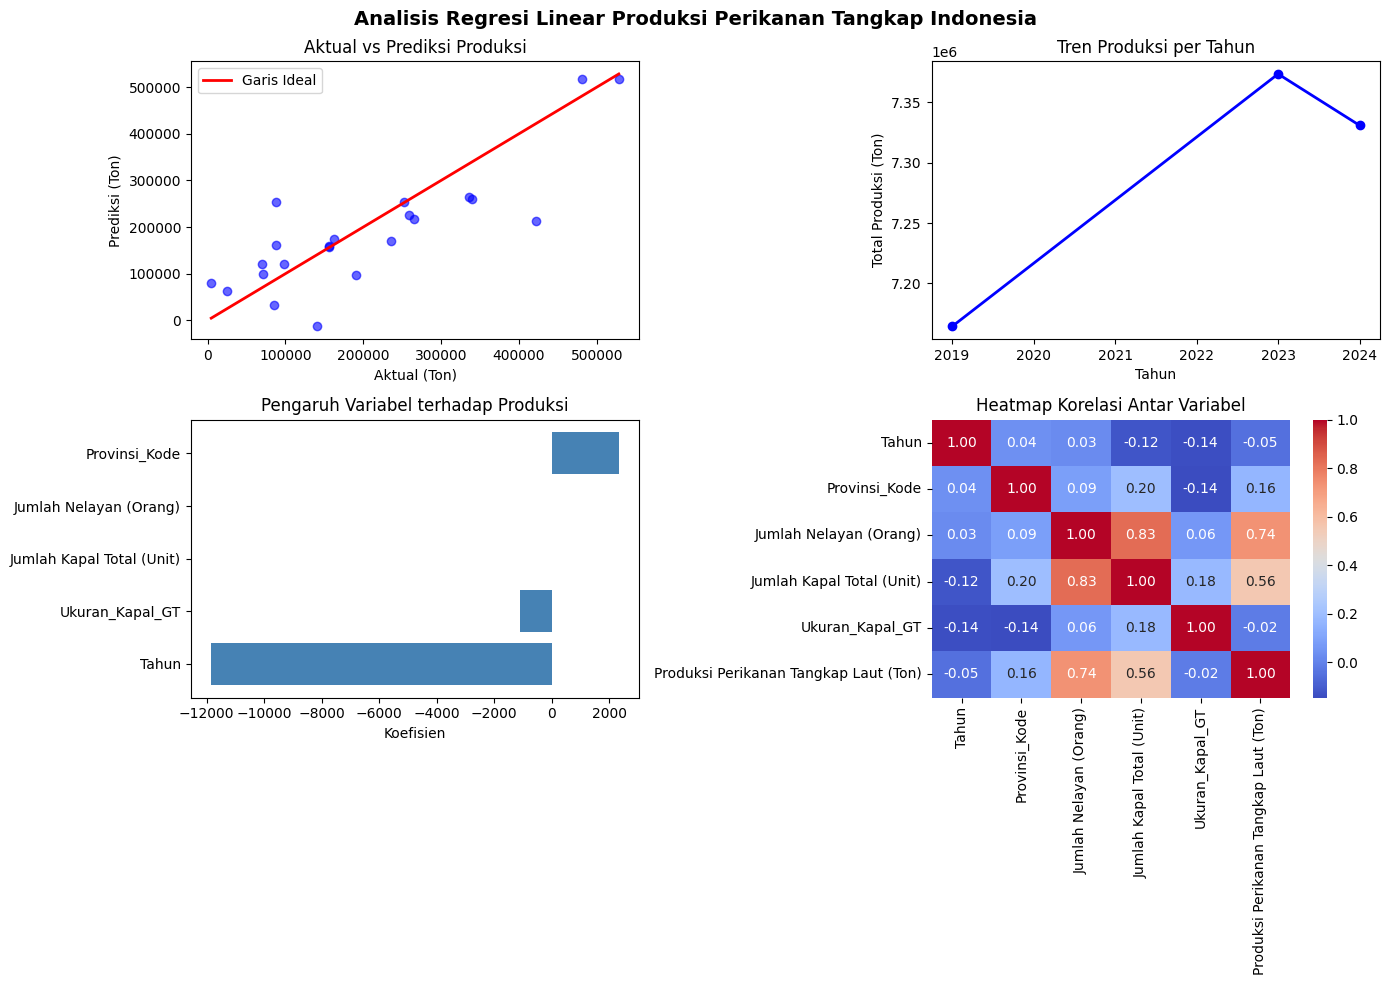

In [ ]:
# VISUALISASI

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Regresi Linear Produksi Perikanan Tangkap Indonesia',
             fontsize=14, fontweight='bold')

# VISUALISASI AKTUAL VS PREDIKSI
# Semakin titik-titik dekat ke garis merah = semakin akurat model
axes[0,0].scatter(y_test, y_pred, color='blue', alpha=0.6)
axes[0,0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()],
               color='red', linewidth=2, label='Garis Ideal')
axes[0,0].set_title('Aktual vs Prediksi Produksi')
axes[0,0].set_xlabel('Aktual (Ton)')
axes[0,0].set_ylabel('Prediksi (Ton)')
axes[0,0].legend()

# VISUALISASI TREN PRODUKSI PER TAHUN
tren = df_new.groupby('Tahun')['Produksi Perikanan Tangkap Laut (Ton)'].sum()
axes[0,1].plot(tren.index, tren.values, marker='o', color='blue', linewidth=2)
axes[0,1].set_title('Tren Produksi per Tahun')
axes[0,1].set_xlabel('Tahun')
axes[0,1].set_ylabel('Total Produksi (Ton)')

# VISUALISASI KOEFISIEN / PENGARUH VARIABEL
# Koefisien positif = menambah produksi, negatif = mengurangi produksi
koef_df = pd.DataFrame({
    'Variabel'  : X.columns,
    'Koefisien' : model.coef_
}).sort_values('Koefisien', ascending=True)
axes[1,0].barh(koef_df['Variabel'], koef_df['Koefisien'], color='steelblue')
axes[1,0].set_title('Pengaruh Variabel terhadap Produksi')
axes[1,0].set_xlabel('Koefisien')

# HEATMAP KORELASI
# Warna merah = korelasi positif kuat, biru = korelasi negatif kuat
sns.heatmap(df_new[[
    'Tahun',
    'Provinsi_Kode',
    'Jumlah Nelayan (Orang)',
    'Jumlah Kapal Total (Unit)',
    'Ukuran_Kapal_GT',
    'Produksi Perikanan Tangkap Laut (Ton)'
]].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    ax=axes[1,1])
axes[1,1].set_title('Heatmap Korelasi Antar Variabel')
plt.tight_layout()
plt.show()

**KESIMPULAM HASIL ANALISIS**

Penelitian ini menganalisis produksi perikanan tangkap laut Indonesia menggunakan metode regresi linear berganda dengan variabel independen berupa tahun, jumlah nelayan, jumlah kapal, dan ukuran kapal (GT), serta variabel dependen berupa total produksi perikanan tangkap laut dalam satuan ton.

Hasil evaluasi model menunjukkan nilai R² sebesar 0.6778, yang berarti model mampu menjelaskan 67.78% variasi produksi perikanan tangkap laut di Indonesia. Sementara itu, nilai RMSE sebesar 80.851 ton menunjukkan rata-rata selisih antara nilai prediksi dan nilai aktual, yang cukup wajar mengingat terdapat perbedaan produksi yang sangat besar antar provinsi di Indonesia.

Berdasarkan analisis korelasi, variabel jumlah nelayan memiliki korelasi paling kuat terhadap produksi perikanan dengan nilai 0.74, diikuti oleh jumlah kapal dengan nilai 0.56. Hal ini menunjukkan bahwa semakin banyak nelayan dan kapal yang beroperasi, semakin tinggi produksi perikanan yang dihasilkan. Sebaliknya, variabel tahun dan ukuran kapal menunjukkan korelasi yang sangat lemah terhadap produksi perikanan.

Dari sisi tren, produksi perikanan tangkap Indonesia mengalami peningkatan dari tahun 2019 hingga mencapai puncaknya pada tahun 2023, kemudian mengalami penurunan pada tahun 2024. Penurunan ini perlu mendapat perhatian lebih lanjut dari pemangku kebijakan sektor perikanan.

Secara keseluruhan, model regresi linear yang dibangun cukup memadai untuk memprediksi produksi perikanan tangkap Indonesia. Namun demikian, terdapat sekitar 32% faktor lain yang belum tercakup dalam model ini, seperti kondisi cuaca, kebijakan penangkapan ikan, dan kondisi ekosistem laut, yang turut mempengaruhi produksi perikanan tangkap di Indonesia.